# Lupus murine spleen CODEX data set - Topological data analysis

Contents:
1. Data preparation and preliminary analysis
2. Persistent homology (PH) computations
3. Visualisation of PH (PWDS)
4. Vectorisations
5. Clustering

In [1]:
# Basic libraries
import numpy as np
import math
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import time

plt.rcParams['font.family'] = 'Arial'
from matplotlib import ticker

# Statistics
import scipy.stats as stats

# Nearest neighbour analysis
from sklearn.neighbors import NearestNeighbors

# Persistence homology
import gudhi
import gudhi.representations.vector_methods # Betti curves computation 
from persim import PersistenceImager # Persistence images computation 
import collections
collections.Iterable = collections.abc.Iterable # Needed for persim

# Dimensionality reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score as sil_score

# Ignore FutureWarnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## 1. Data preparation and preliminary analysis

In [2]:
# Global variables (can be changed depending on data set)

stages = ['healthy','early','intermediate','late']
stages_colors = ['blue','orange','red','firebrick']
line_styles = ['solid', 'dashed', 'dashdot', 'dotted']
stages_len = [3,3,2,1]

### Load data

9 samples of cell spatial distribution from mouse spleen:
- 3 __healthy__ samples: BALB-1, BALBc-2, BALBc-3
- 6 samples from spleen with __lupus (autoimmune disease)__, by stage:
    - MRL-4, -5, -6: early
    - MRL-7, -8: intermediate
    - MRL-9: late

Each sample is divided in 7 x 9 tiles (7 horizontal, 9 vertical) which we will stitch together.
Each row of the data set contains the information of a single cell. The relevant columns are:
- ```Imaging phenotype cluster ID```: code that identifies the type of cell. List of cell types and their respective codes is taken from mm2.xlsx.
- ```sample_Xtile_Ytile```: sample and tile position, e.g. BALBc-2_X02_Y08
- ```X.X```: x-coordinate of the cell
- ```Y.Y```: x-coordinate of the cell

In [3]:
df_cells = pd.read_csv('data/MRLdatasetexpression.csv', index_col = None) # Data
df_mmc = pd.read_excel('data/mmc2.xlsx') # Cell type corresponding to each Imaging phenotype cluster ID

# Find the list of names of samples. 9 samples:
indices = df_cells.sample_Xtile_Ytile.value_counts().index.tolist()
samples = sorted(list(set([item.split("_")[0] for item in indices]))) # Alphabetically sorted

# Find the list of ID, except cells classified as dirt, noid, or capsule which we discard. 25 cell types:
notincluded = ['dirt','noid','capsule']
cell_types = df_mmc[~df_mmc["Imaging phenotype (cell type)"].isin(notincluded)]["Imaging phenotype (cell type)"].value_counts().index.tolist()

# Order the cell types by relevance (total number of cells present in the samples)
ct_num = []

for ct in cell_types:
    IDs = df_mmc[df_mmc["Imaging phenotype (cell type)"]==ct]["X-shift cluster ID"].values
    ct_num.append(len(df_cells[(df_cells["Imaging phenotype cluster ID"].isin(IDs))]))

cell_types = [x for _, x in sorted(zip(ct_num, cell_types), key=lambda pair: pair[0],reverse=True)]

/home/torrasperez/Documents/Multiplexed data analysis/tda-venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


The spleen has two parts, the red pulp and the white pulp. According to the findings in the original article, the cell types corresponding to these two parts are the following.

In [4]:
broad_cell_types = ['red pulp', 'white pulp'] 

bct2ct = {
    'red pulp': [
        #'capsule',
        'CD31(hi) vascular',
        'plasma cells',
        'CD106(-)CD16/32(-)Ly6C(+)CD31(+) stroma',
        'CD4(+)CD8(-)cDC',
        'ERTR7(+) stroma',
        'CD4(+)MHCII(+)',
        'CD4(-)CD8(-) cDC',
        'CD4(-)CD8(+)cDC',
        'CD106(+)CD16/32(-)Ly6C(+)CD31(+)',
        'megakaryocytes',
        'CD106(-)CD16/32(+)Ly6C(+)CD31(-)',
        'CD106(+)CD16/32(+)CD31(+) stroma',  # In the article it appears as CD106(+)CD16/32(+)Ly6C(-)CD31(+) stroma
        'granulocytes',
        'CD3(+) other markers (-)',
        'NK cells',
        'F4/80(+) mphs',
        'erythroblasts',
        'CD11c(+) B cells',
        'CD106(+)CD16/32(+)CD31(-)Ly6C(-) stroma',
    ],
    'white pulp': [
        'FDCs',
        'marginal zone mphs',
        'B cells',
        'CD8(+) T cells',
        'CD4(+) T cells',
        # 'noid'
        'B220(+) DN T cells',
    ]
} 

We stitch the tiles together and separate by cell type and broad cell types.

In [5]:
point_clouds = {}

xtilespan = 1344
ytilespan = 1008

for sample in samples:
    for ct in cell_types:
        IDs = df_mmc[df_mmc["Imaging phenotype (cell type)"]==ct]["X-shift cluster ID"].values
        # extract relevant rows
        tile_cells = df_cells[(df_cells['sample_Xtile_Ytile'].str.startswith(sample))
                         & (df_cells["Imaging phenotype cluster ID"].isin(IDs))]
        x_positions = tile_cells['sample_Xtile_Ytile'].str.split("_").str[1].str[2].astype(int).values
        y_positions = tile_cells['sample_Xtile_Ytile'].str.split("_").str[2].str[2].astype(int).values

        x = tile_cells["X.X"].values + xtilespan*(x_positions-1)
        y = tile_cells["Y.Y"].values + ytilespan*(y_positions-1)
        
        point_clouds[sample,ct]=[x,y]

for bct in broad_cell_types:
  for sample in samples:    
      x = np.array([])
      y = np.array([])
      for ct in bct2ct[bct]:
          x = np.concatenate((x,point_clouds[sample,ct][0]),axis=None)
          y = np.concatenate((y,point_clouds[sample,ct][1]),axis=None)     
      point_clouds[sample,bct] = [x,y]

### Plot data and densities

In [6]:
# Choose colors
colors_ct = ['#3cb44b', '#4363d8', '#e6194B', '#911eb4', '#ffe119', '#f58231', '#42d4f4', '#f032e6', '#bfef45', \
          '#fabed4', '#469990', '#dcbeff', '#9A6324', '#fffac8', '#800000', '#aaffc3', '#808000', '#ffd8b1', \
          '#000075', '#a9a9a9', '#000000', '#4c005c', '#94ffb5', '#005c31', '#990000']

# Colors are globally attributed by cell counts, regardless of the pulp
ct2color = {cell_types[i]:colors_ct[i] for i in range(len(cell_types))}

ct2color['red pulp'] = '#ff7f0e'
ct2color['white pulp'] = '#1f77b4'

#### All cell types

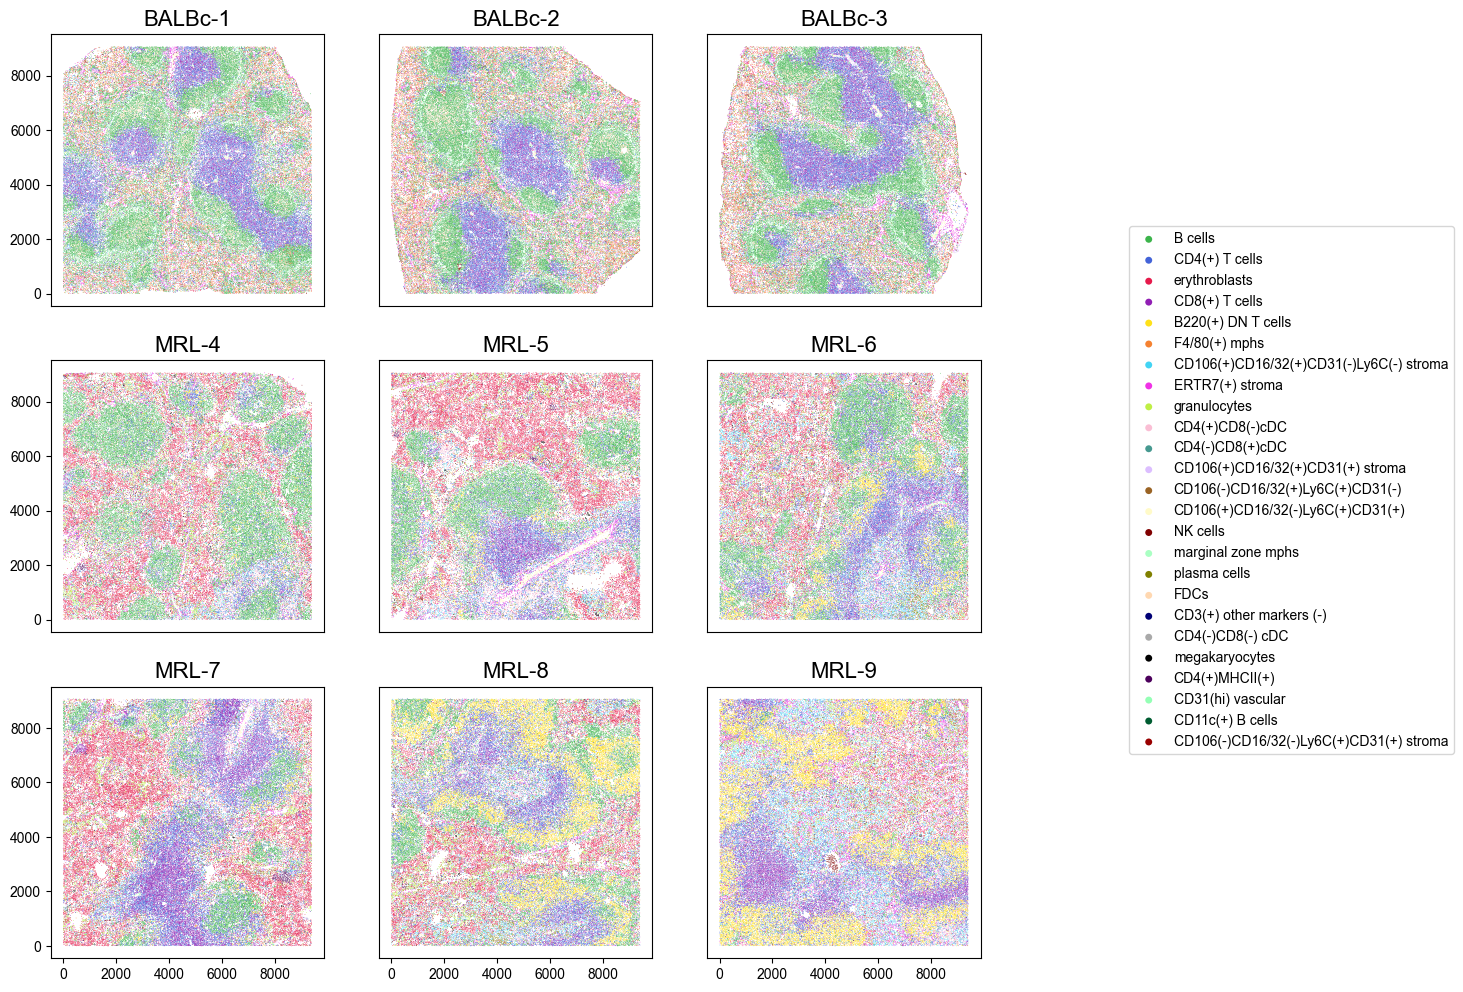

In [7]:
# Plot all cell types

fig, axs = plt.subplots(3, 3, figsize=(12, 12))

for i in range(0,len(samples)):    
    sample = samples[i]
    ax = axs[math.floor(i/3), i%3]
    ax.set_title(sample, fontsize=16)
    for j in range(0,len(cell_types)):
        ct = cell_types[j]
        x = point_clouds[sample,ct][0]
        y = point_clouds[sample,ct][1]
        ax.scatter(x, y, label = ct, s=1, marker = '.', edgecolors ='none', c=ct2color[ct])
        if i%3!= 0:
            ax.set_yticks([], [])
        if i<=5:
            ax.set_xticks([], [])

handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))       
lgnd = fig.legend(by_label.values(), by_label.keys(),loc='center right',bbox_to_anchor=(1.3, 0.5))

for i in range(0,len(cell_types)):
    lgnd.legend_handles[i]._sizes = [100]

#### Individual cell type

In [8]:
# Choose a cell type (or broad cell type)

ct = 'white pulp'

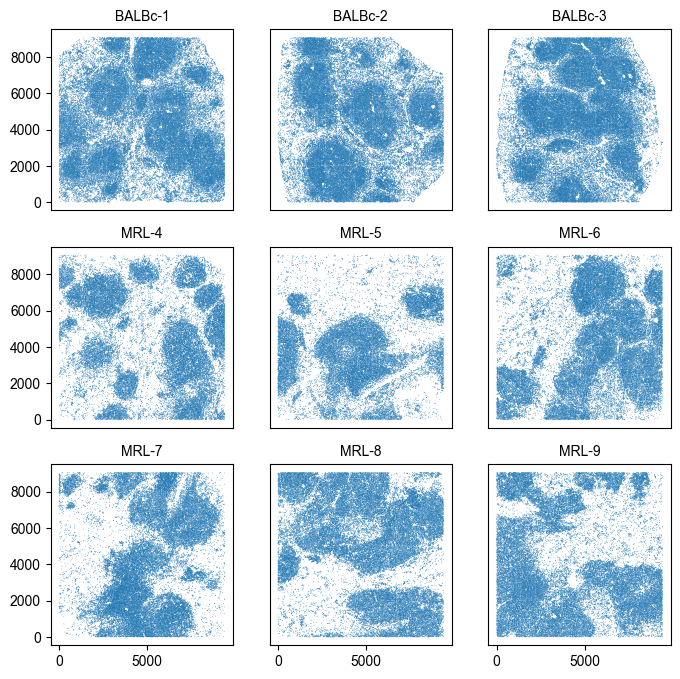

In [9]:
# Plot a specific cell type (or broad cell type)

fig, axs = plt.subplots(3, 3, figsize=(8, 8))

for i in range(0,len(samples)):    
    sample = samples[i]
    ax = axs[math.floor(i/3), i%3]
    ax.set_title(sample, fontsize=10)
    x = point_clouds[sample,ct][0]
    y = point_clouds[sample,ct][1]
    ax.scatter(x, y, label = ct, s=1, marker = '.', edgecolors ='none', c=ct2color[ct])
    if i%3!= 0:
        ax.set_yticks([], [])
    if i<=5:
        ax.set_xticks([], [])

### Density analysis

p-value of the t-test comparing the densities in the healthy and diseased samples

In [10]:
densities_pvalue = {}
densities = {}

for ct in broad_cell_types + cell_types:
    feature = [len(point_clouds[sample, ct][0]) for sample in samples]
    densities[ct] = feature
    densities_pvalue[ct] = stats.ttest_ind(feature[0:stages_len[0]], feature[stages_len[0]:stages_len[0]+sum(stages_len[1:])], axis=0, equal_var=False, alternative='two-sided').pvalue

Text(0.5, 1.0, '')

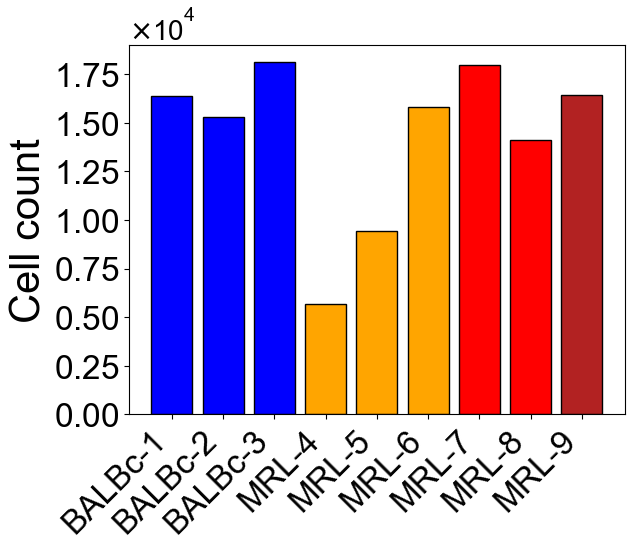

In [11]:
ct = 'CD4(+) T cells'

heights = densities[ct]

# Define the number of bins (you can adjust this based on your data)
bins = len(samples)

# Define colours
colors_hist = ['blue'] * stages_len[0] + ['orange'] * stages_len[1] + ['red'] * stages_len[2] + ['firebrick'] * stages_len[3]

# Create the bar plot
bars = plt.bar(range(len(samples)), heights, color=colors_hist, edgecolor='black')

# Set the custom x-ticks (labels) and remove numeric labels
plt.xticks(range(len(samples)), labels=samples, rotation=45, ha='right', size=24)
plt.yticks(size = 24)

plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0)) #, scilimits=None, useOffset=None, useLocale=None, useMathText=None)

# Increase the font size of the scientific offset in the top-left corner
offset_text = plt.gca().yaxis.get_offset_text()
offset_text.set_visible(True)
offset_text.set_fontsize(20) 

# Set labels and title
plt.ylabel("Cell count", size = 30)
plt.title("")

### Nearest neighbour distance

We compute the nearest neighbour distance between cells and take the global mean across all samples. In the paper we call this parameter $d$, here it is saved in the variable nnd_mean.

In [12]:
nn = NearestNeighbors(n_neighbors=1, radius=100.0, metric='minkowski', p=2) # Euclidian metric

nn_distances = []

for sample in samples:
    x = list(point_clouds[sample, 'red pulp'][0]) + list(point_clouds[sample, 'white pulp'][0])
    y = list(point_clouds[sample, 'red pulp'][1]) + list(point_clouds[sample, 'white pulp'][1])
    data = np.vstack((x,y)).T
    nn.fit(data)
    nn_distances = nn_distances + list(nn.kneighbors()[0])

print('Nearest Neighbour distance (global):')
print('mean: ', np.mean(nn_distances))
print('std: ', np.std(nn_distances))

nnd_mean = np.mean(nn_distances)

Nearest Neighbour distance (global):
mean:  20.765392490622933
std:  6.9652114796544184


### Functions for analysis

#### Create class of topological descriptors

In [13]:
class topological_descriptor:
    def __init__(self, vectors, point_cloud, filtration, degree, type):
        self.vectors = vectors
        self.point_cloud = point_cloud
        self.filtration = filtration
        self.degree = degree
        self.type = type
        self.label = ' '.join([self.point_cloud, self.filtration, 'H'+str(self.degree), self.type])
        self.pi_shape = None
        self.twoclust = None
        self.fourclust = None
        self.threeclust = None

#### Computation of Betti curves

In [14]:
# Computation of Betti curve

def betti_curves(dgms_list, step, normalise = True):
    min_param = 0
    max_param = math.ceil(np.vstack(dgms_list).max(axis=0)[1])
    bc = gudhi.representations.vector_methods.BettiCurve(resolution=None, predefined_grid=np.array(range(min_param,max_param,step)))

    betti_curves = []

    for i in range(len(samples)):
        if normalise == True:
            norm = len(dgms_list[i])
        else:
            norm = 1
        betti_curves.append(np.array(bc(dgms_list[i])/norm))
    
    return betti_curves


#### Plotting of Betti curves

In [15]:
def plot_betti_curves(curves, step, figsize = (10,3), legend = False, pos_legend = (1.1,0.6), title = '', save = False, filename = '', max_param = np.inf, min_param = 0, max_y = np.inf):

    global stages_colors, line_styles, stages, stages_len

    plt.style.use('default')
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    if max_param == np.inf:
        max_param = len(curves[0]) # All betti curves need to have the same length, they will if computed with my function 
    
    if max_y < np.inf:
        plt.ylim(-0.01,max_y)
    
    plt.xlabel('Scale parameter value',size = 20,labelpad=10)
    plt.ylabel('Proportion of\nlive features',size = 20, labelpad=10) # 'Proportion of \n live features', rotation='horizontal')
    plt.xticks(size = 16)
    plt.yticks(size = 16)

    count = 0
    for i in range(len(stages)):
        s = stages[i]

        for j in range(stages_len[i]):
            plt.plot(np.array(range(min_param,max_param,step)),curves[count + j][min_param:max_param], \
                     color=stages_colors[i], linestyle = line_styles[i], linewidth=1, label = s) # s = 0.2)

        count = count + stages_len[i]

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))       
        lgnd = fig.legend(by_label.values(), by_label.keys(),bbox_to_anchor=pos_legend)

        for i in range(0,len(stages)):
            lgnd.legend_handles[i]._sizes = [15]

    if save == True:
        fig.savefig(filename,facecolor='white', transparent=False,dpi=200, bbox_inches = 'tight')
    
    return fig

In [16]:
def plot_betti_curves_diseased(curves, step, figsize = (10,3), legend = False, pos_legend = (1.1,0.6), title = '', save = False, filename = '', max_param = np.inf, min_param = 0, max_y = np.inf):

    global stages_colors, line_styles, stages, stages_len

    plt.style.use('default')
    fig = plt.figure(figsize=figsize)
    fig.suptitle(title)

    if max_param == np.inf:
        max_param = len(curves[0]) # All betti curves need to have the same length, they will if computed with my function 
    
    if max_y < np.inf:
        plt.ylim(-0.01,max_y)
    
    plt.xlabel('Scale parameter value')
    plt.ylabel('Proportion of live features') # 'Proportion of \n live features', rotation='horizontal')
    
    
    count = 0
    for i in range(1,len(stages)):
        s = stages[i]

        for j in range(stages_len[i]):
            plt.plot(np.array(range(0,max_param*step,step)),curves[count + j], \
                     color=stages_colors[i], linestyle = line_styles[i-1], linewidth=1, label = s) # s = 0.2)

        count = count + stages_len[i]

    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))       
        lgnd = fig.legend(by_label.values(), by_label.keys(),bbox_to_anchor=pos_legend)

        for i in range(0,len(stages)-1):
            lgnd.legend_handles[i]._sizes = [15]

    if save == True:
        fig.savefig(filename,facecolor='white', transparent=False,dpi=200, bbox_inches = 'tight')
    
    return fig

#### Computation of elementary statistics

In [17]:
# Copied definition from topological_descriptor library

def GetPersStats(barcode,app=False,*p):
    if (np.size(barcode) > 0):
        # Average of Birth and Death of the barcode
        bc_av0, bc_av1 = np.mean(barcode, axis=0)
        # STDev of Birth and Death of the barcode
        bc_std0, bc_std1 = np.std(barcode, axis=0)
        # Median of Birth and Death of the barcode
        bc_med0, bc_med1 = np.median(barcode, axis=0)
        # Intercuartil range of births and death
        bc_iqr0, bc_iqr1 = np.subtract(*np.percentile(barcode, [75, 25], axis=0)) 
        # Range of births and deaths
        bc_r0, bc_r1=np.max(barcode, axis=0) - np.min(barcode, axis=0)
        # Percentiles of births and deaths
        bc_p10_0,bc_p10_1=np.percentile(barcode, 10, axis=0)
        bc_p25_0,bc_p25_1=np.percentile(barcode,25, axis=0)
        bc_p75_0,bc_p75_1=np.percentile(barcode, 75, axis=0)
        bc_p90_0,bc_p90_1=np.percentile(barcode, 90, axis=0)
        
        
        avg_barcodes = (barcode[:,1] + barcode[:,0])/2
        # Average of midpoints of the barcode
        bc_av_av = np.mean(avg_barcodes)
        # STDev of midpoints of the barcode
        bc_std_av = np.std(avg_barcodes)
        # Median of midpoints of the barcode
        bc_med_av = np.median(avg_barcodes)
        # Intercuartil range of midpoints
        bc_iqr_av = np.subtract(*np.percentile(avg_barcodes, [75, 25])) 
        # Range of midpoints
        bc_r_av = np.max(avg_barcodes) - np.min(avg_barcodes)
        # Percentiles of midpoints
        bc_p10_av = np.percentile(barcode, 10)
        bc_p25_av=np.percentile(barcode,25)
        bc_p75_av=np.percentile(barcode, 75)
        bc_p90_av=np.percentile(barcode, 90)
        
        diff_barcode = np.subtract([i[1] for i in barcode], [
                                   i[0] for i in barcode])
        diff_barcode = np.absolute(diff_barcode)
        # Average of the length of Bars
        bc_lengthAverage = np.mean(diff_barcode)
        # STD of length of Bars
        bc_lengthSTD = np.std(diff_barcode)
        # Median of length of Bars
        bc_lengthMedian = np.median(diff_barcode)
        # Intercuartil range of length of the bars
        bc_lengthIQR= np.subtract(*np.percentile(diff_barcode, [75, 25]))
        # Range of length of the bars
        bc_lengthR=np.max(diff_barcode) - np.min(diff_barcode)
        # Percentiles of lengths of the bars
        bc_lengthp10=np.percentile(diff_barcode, 10)
        bc_lengthp25=np.percentile(diff_barcode, 25)
        bc_lengthp75=np.percentile(diff_barcode, 75)
        bc_lengthp90=np.percentile(diff_barcode, 90)
        
        # Number of Bars
        bc_count = len(diff_barcode)
        # Persitent Entropy
        # ent = GetNewMethods.Entropy()
        # bc_ent = ent.fit_transform([barcode])
        
        bar_stats = np.array([bc_av0, bc_av1, bc_std0, bc_std1, bc_med0, bc_med1,
                              bc_iqr0, bc_iqr1, bc_r0, bc_r1, bc_p10_0, bc_p10_1, 
                              bc_p25_0, bc_p25_1, bc_p75_0, bc_p75_1, bc_p90_0, 
                              bc_p90_1, 
                              bc_av_av, bc_std_av, bc_med_av, bc_iqr_av, bc_r_av, bc_p10_av, 
                              bc_p25_av, bc_p75_av, bc_p90_av, bc_lengthAverage, bc_lengthSTD, 
                              bc_lengthMedian, bc_lengthIQR, bc_lengthR, bc_lengthp10,  
                              bc_lengthp25,  bc_lengthp75,  bc_lengthp90, bc_count])
        if app == True:
            bar_stats = np.array([bc_av0, bc_std0, bc_med0, bc_iqr0, bc_r0, bc_p10_0, bc_p25_0, bc_p75_0, bc_p90_0,
                              bc_av1, bc_std1, bc_med1, bc_iqr1, bc_r1, bc_p10_1, bc_p25_1, bc_p75_1, bc_p90_1,
                              bc_av_av, bc_std_av, bc_med_av, bc_iqr_av, bc_r_av, bc_p10_av, bc_p25_av, bc_p75_av, bc_p90_av,
                              bc_lengthAverage, bc_lengthSTD, bc_lengthMedian, bc_lengthIQR, bc_lengthR, bc_lengthp10, bc_lengthp25, bc_lengthp75, bc_lengthp90,
                              bc_count])
    else:
        bar_stats = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 
                              0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
                              0, 0,0, 0])

    bar_stats[~np.isfinite(bar_stats)] = 0

    return bar_stats

#### Analysis of clustering results

In [18]:
# Compare clusterings.

# Relabel to make comparisson easier

def relabel(clustering, new_labels = None):
    labels = list(dict.fromkeys(clustering)) # Eliminate duplicates while preserving the original order of appearance
    if new_labels == None:
        new_labels = range(len(labels)) # Relabel by integers
    translation = dict(zip(labels,new_labels))
    new_clustering = [translation[l] for l in clustering]
    return new_clustering

def good_clustering(clustering, true_labels):  
    if relabel(clustering) == relabel(true_labels):
        return True
    else:
        return False

def partial_clustering(clustering, true_labels, some_labels):

    clust = relabel(clustering)
    truth = relabel(true_labels)

    # Need to translate some_labels, which are a subset of true_labels
    labels = list(dict.fromkeys(true_labels))
    new_labels = range(len(labels))
    translation = dict(zip(labels,new_labels))
    some = [translation[l] for l in some_labels]

    clust_ = []
    for a in clust:
        if a in some:
            clust_.append(a)
        else:
            clust_.append(np.inf)

    truth_ = []
    for a in truth:
        if a in some:
            truth_.append(a)
        else:
            truth_.append(np.inf)

    if clust_ == truth_:
        return True
    else:
        return False



In [19]:
def label2cluster(labels, objects):
    clusters = {}
    label_set = set(labels)
    for l in label_set:
        clusters[l] = []
    
    for i in range(len(labels)):
        clusters[labels[i]].append(objects[i])
    
    return clusters

#### Plotting of PCAs

In [20]:
# Define a PCA function tailored for our dataset.

def plot_pca(feature, n_comp = 2, title = '', legend = True, save = False, ticks = True, filename = ''): 
    
    global stages_colors, stages, stages_len
    
    pca = PCA(n_components=n_comp)
    
    feature_pca = (pca.fit_transform(feature)).T

    fig, ax = plt.subplots() #figsize=(12,8)

    fig.suptitle(title)
    plt.axis('equal')
    plt.xlabel('PC1',size = 32)
    plt.ylabel('PC2', size = 32)

    count = 0

    for i in range(len(stages)):
        s = stages[i]

        ax.scatter(feature_pca[0][count:count+stages_len[i]], feature_pca[1][count:count+stages_len[i]], s = 100, 
                   color=stages_colors[i],label=s)

        count = count + stages_len[i]

    if not ticks:
        ax.set_xticks([],[])
        ax.set_yticks([],[])
    
    if legend:
        handles, labels = plt.gca().get_legend_handles_labels()
        by_label = dict(zip(labels, handles))       
        lgnd = fig.legend(by_label.values(), by_label.keys(),bbox_to_anchor=(1.15, 0.6))

        for i in range(0,len(stages)):
            lgnd.legend_handles[i]._sizes = [15]
    
    
    if save:
        fig.savefig(filename,dpi=200, bbox_inches = 'tight')

    return fig

In [21]:
# Define a PCA function tailored for our dataset only for diseased samples.

def plot_pca_diseased(feature, n_comp = 2, title = '', save = False, filename = '', clustering = None):
    
    global stages_colors, stages, stages_len
    
    pca = PCA(n_components=n_comp)
    
    feature_pca = (pca.fit_transform(feature[stages_len[0]:])).T

    fig, ax = plt.subplots() #figsize=(12,8)

    fig.suptitle(title)
    plt.axis('equal')
    plt.xlabel('PC1')
    plt.ylabel('PC2')

    count = 0

    # Markers to indicate clustering work, but need to sort out legend
    
    if clustering != None:
        markers = relabel(clustering,new_labels=["o","x","s"])

    if clustering == None:
        markers = len(feature)*["o"]

    for i in range(1,len(stages)):
        s = stages[i]

        for j in range(count,count+stages_len[i]):
            ax.scatter(feature_pca[0][j], feature_pca[1][j], s = 10, 
                       color=stages_colors[i],label=s, marker=markers[j])
        
        count = count + stages_len[i]

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))       
    lgnd = fig.legend(by_label.values(), by_label.keys(),bbox_to_anchor=(1.15, 0.6))

    for i in range(0,len(stages)-1):
        lgnd.legend_handles[i]._sizes = [15]
    
    if save:
        fig.savefig(filename,dpi=200, bbox_inches = 'tight')

    return fig

## 2. Persistent homology computations

In [22]:
dgms = {} 

In [23]:
deg_max = 1 # We compute up to degree 1 homology (clusters and loops) 
filtrations = ['alpha', 'witness'] 

### Alpha filtration

In [24]:
alpha_dgms = {}

# Create empty lists to save persistence diagrams
for ct in cell_types + broad_cell_types:
    alpha_dgms[ct] = [[] for _ in range(deg_max+1)]

In [25]:
min_pers = 0    # We don't rule out features of very low persistence

for ct in broad_cell_types + cell_types:
    for sample in samples:
        data = np.vstack((point_clouds[sample,ct][0], point_clouds[sample,ct][1])).T
        
        # Computation of persistent homology 
        stree = gudhi.AlphaComplex(points = data).create_simplex_tree()
        dgm_raw = stree.persistence(min_persistence=min_pers)

        dgm_rearranged = [[] for _ in range(deg_max+1)] # We rearrange the format of the persistence diagrams
        for point in dgm_raw:
            dgm_rearranged[point[0]].append([np.sqrt(point[1][0]),np.sqrt(point[1][1])]) # gudhi works with the square of the scale parameter for computational reasons, we take sqrt
        
        alpha_dgms[ct][0].append(np.array(dgm_rearranged[0][1:])) # Take out infinity point
        alpha_dgms[ct][1].append(np.array(dgm_rearranged[1]))

In [26]:
dgms['alpha'] = alpha_dgms

### Witness filtration

We only compute PH with the witness filtration for the largest point clouds: the red and white pulps.

#### Upload pre-computed results

In [27]:
witness_dgms = {}

for ct in broad_cell_types:
    # Initialize: one list per degree, and inside each, one list per sample
    witness_dgms[ct] = [[[] for _ in samples] for _ in range(deg_max + 1)]

    with open('witness_' + ct.replace(' ', '_') + ".txt", "r") as f:
        for line in f:
            if line.startswith("#"):
                continue  # Skip sample name lines
            i_str, dim_str, b_str, d_str = line.strip().split()
            i = int(i_str)
            dim = int(dim_str)
            b = float(b_str)
            d = float(d_str)
            b_sqrt = np.sqrt(b)
            d_sqrt = np.sqrt(d)

            # Append directly to the appropriate degree and sample
            witness_dgms[ct][dim][i].append([b_sqrt, d_sqrt])

    # Convert inner lists to numpy arrays, and exclude the first H0 point
    for dim in range(deg_max + 1):
        for i in range(len(samples)):
            arr = np.array(witness_dgms[ct][dim][i])
            if dim == 0:
                witness_dgms[ct][dim][i] = arr[1:]  # Exclude first point in H0 (essential feature, death = infty)
            else:
                witness_dgms[ct][dim][i] = arr

In [28]:
dgms['witness'] = witness_dgms

#### Plot landmark points

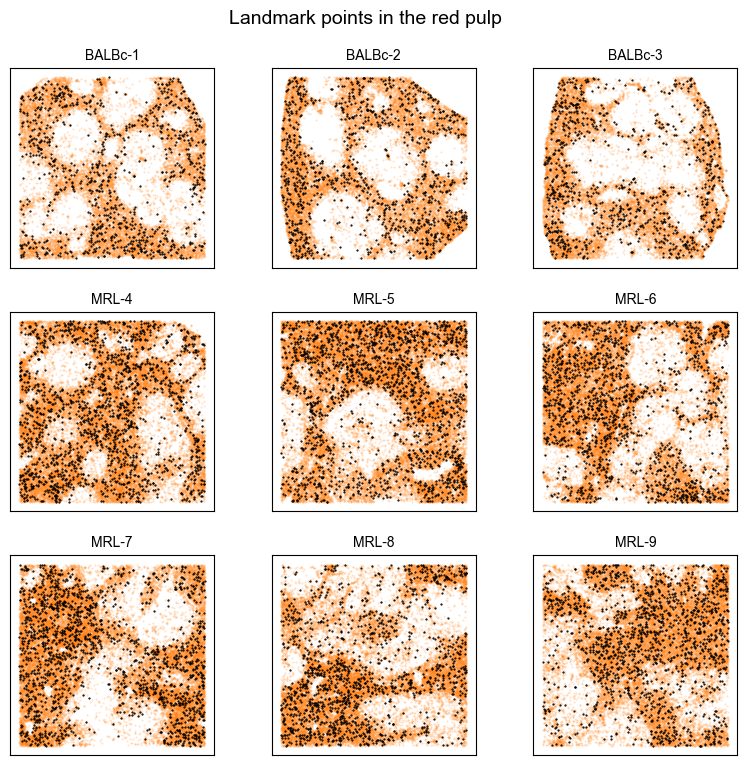

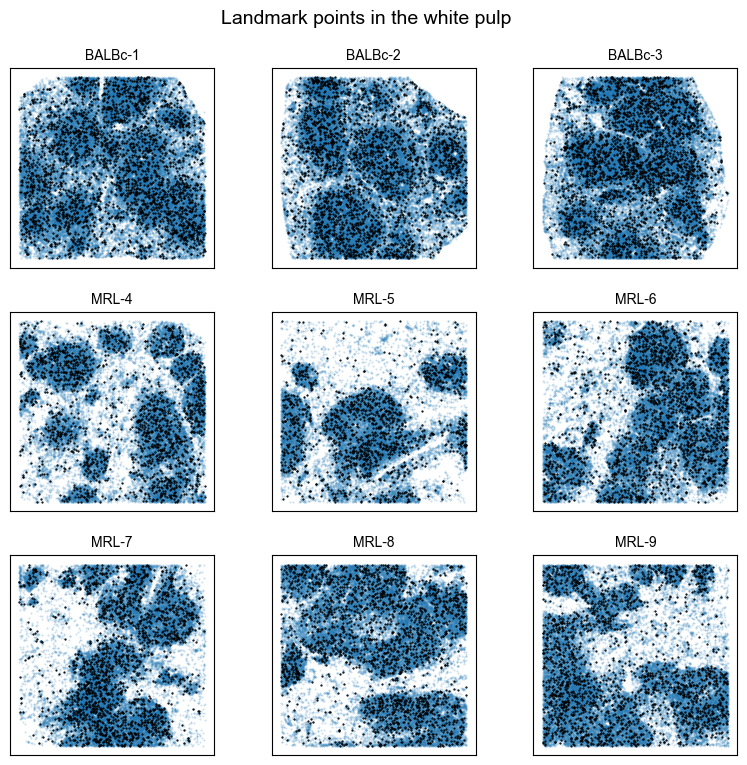

In [29]:
# Plot landmark points

for ct in broad_cell_types:

    # LOAD PYTHON OBJECT landmarks
    landmarks = {}
    current_sample = None
    x_l = []
    y_l = []

    with open('landmarks_' + ct.replace(' ', '_') + ".txt", "r") as f:
        for line in f:
            if line.startswith("#"):
                if current_sample is not None:
                    landmarks[current_sample] = [np.array(x_l), np.array(y_l)]
                current_sample = line[1:].strip()
                x_l = []
                y_l = []
            else:
                x_str, y_str = line.strip().split()
                x_l.append(float(x_str))
                y_l.append(float(y_str))
        # Save last sample
        if current_sample is not None:
            landmarks[current_sample] = [np.array(x_l), np.array(y_l)]

    # Plot landmarks
    fig, axs = plt.subplots(3, 3, figsize=(8, 8))
    fig.suptitle('Landmark points in the '+ ct +'\n', fontsize=14)
    fig.tight_layout()

    for i in range(len(samples)):    
        sample = samples[i]
        x = point_clouds[sample, ct][0]
        y = point_clouds[sample, ct][1]
        x_l = landmarks[sample][0]
        y_l = landmarks[sample][1]
        
        ax = axs[math.floor(i/3), i%3]
        ax.scatter(x, y, s=0.2,color=ct2color[ct],alpha=0.25)
        ax.scatter(x_l, y_l, s=0.3,color='black')
        
        ax.set_title(sample, fontsize=10)
        ax.set_xticks([], [])
        ax.set_yticks([], [])

#### Computations (de-activated)

##### Red pulp

In [30]:
ct = 'red pulp'

In [31]:
# DE-ACTIVATED

# Choose landmark points

# landmark_ratio = 20 # density parameter

# rp_landmarks = {}

# for sample in samples:
#     x = point_clouds[sample, ct][0]
#     y = point_clouds[sample,ct][1]
#     data = np.vstack((x,y)).T

#     num_landmarks = math.ceil(len(data)/landmark_ratio) # Recommended in de Silva and Carlsson paper
#     idx = np.random.randint(len(data), size=num_landmarks)
    
#     #rp_landmarks[sample] = data[idx,:].T

# # SAVE landmark points as plain text
# with open('landmarks_red_pulp.txt', 'w') as f:
#     for sample in samples:
#         x_l, y_l = landmarks[sample]
#         f.write(f"# {sample}\n")
#         for x, y in zip(x_l, y_l):
#             f.write(f"{float(x)} {float(y)}\n")

In [32]:
# rp_witness_dgms = [[] for _ in range(len(samples))]
# max_alpha2 = [700000, 3000000, 700000, 200000, 400000, 200000, 300000, 200000, 300000]

In [33]:
# DE-ACTIVATED

# for i in range(len(samples)):
#     sample = samples[i]
    
#     st = time.time()
    
#     x = point_clouds[sample,ct][0]
#     y = point_clouds[sample,ct][1]
#     data = np.vstack((x,y)).T
    
#     witness_complex = gudhi.EuclideanWitnessComplex(witnesses=data, landmarks=rp_landmarks[sample].T)
#     simplex_tree = witness_complex.create_simplex_tree(max_alpha_square=max_alpha2[i], limit_dimension=2)
#     #rp_witness_dgms[i] = simplex_tree.persistence()
    
#     et = time.time()
#     print(sample + ':', round((et - st)/60), 'minutes')

# # SAVE PYTHON OBJECT
# with open('witness_red_pulp.txt", "w") as f:
#     for i, (sample_name, dgm) in enumerate(zip(samples, rp_witness_dgms)):
#         f.write(f"# {sample_name}\n")  # Comment line with sample name
#         for dim, (b, d) in dgm:
#             f.write(f"{i} {dim} {repr(b)} {repr(d)}\n")

##### White pulp

In [34]:
ct = 'white pulp'

In [35]:
# DE-ACTIVATED

# Choose landmark points

# landmark_ratio = 20 # density parameter

# wp_landmarks = {}

# for sample in samples:
#     x = point_clouds[sample,ct][0]
#     y = point_clouds[sample,ct][1]
#     data = np.vstack((x,y)).T

#     num_landmarks = math.ceil(len(data)/landmark_ratio) # Recommended in de Silva and Carlsson paper
#     idx = np.random.randint(len(data), size=num_landmarks)
    
#     #wp_landmarks[sample] = data[idx,:].T

# # SAVE landmark points as plain text
# with open('landmarks_white_pulp.txt', 'w') as f:
#     for sample in samples:
#         x_l, y_l = landmarks[sample]
#         f.write(f"# {sample}\n")
#         for x, y in zip(x_l, y_l):
#             f.write(f"{float(x)} {float(y)}\n")

In [36]:
# wp_witness_dgms = [[] for _ in range(0,9)]
# max_alpha2 = [700000]*len(samples)

In [37]:
# DE ACTIVATED

# for i in range(len(samples)):
#     sample = samples[i]
    
#     st = time.time()
    
#     x = point_clouds[sample,ct][0]
#     y = point_clouds[sample,ct][1]
#     data = np.vstack((x,y)).T
    
#     # witness_complex = gudhi.EuclideanWitnessComplex(witnesses=data, landmarks=wp_landmarks[sample].T)
#     # simplex_tree = witness_complex.create_simplex_tree(max_alpha_square=max_alpha2[i], limit_dimension=2)
#     # wp_witness_dgms[i] = simplex_tree.persistence()
    
#     et = time.time()
#     print(sample + ':', round((et - st)/60), 'minutes')

# # SAVE PYTHON OBJECT
# with open('witness_white_pulp.txt", "w") as f:
#     for i, (sample_name, dgm) in enumerate(zip(samples, wp_witness_dgms)):
#         f.write(f"# {sample_name}\n")  # Comment line with sample name
#         for dim, (b, d) in dgm:
#             f.write(f"{i} {dim} {repr(b)} {repr(d)}\n")

### Visualise persistence diagrams

In [38]:
# Choose cell type, degree of homology (0 or 1) and filtration ('alpha' or 'witness'):
ct = 'CD11c(+) B cells'
degree = 1
filtration = 'alpha'

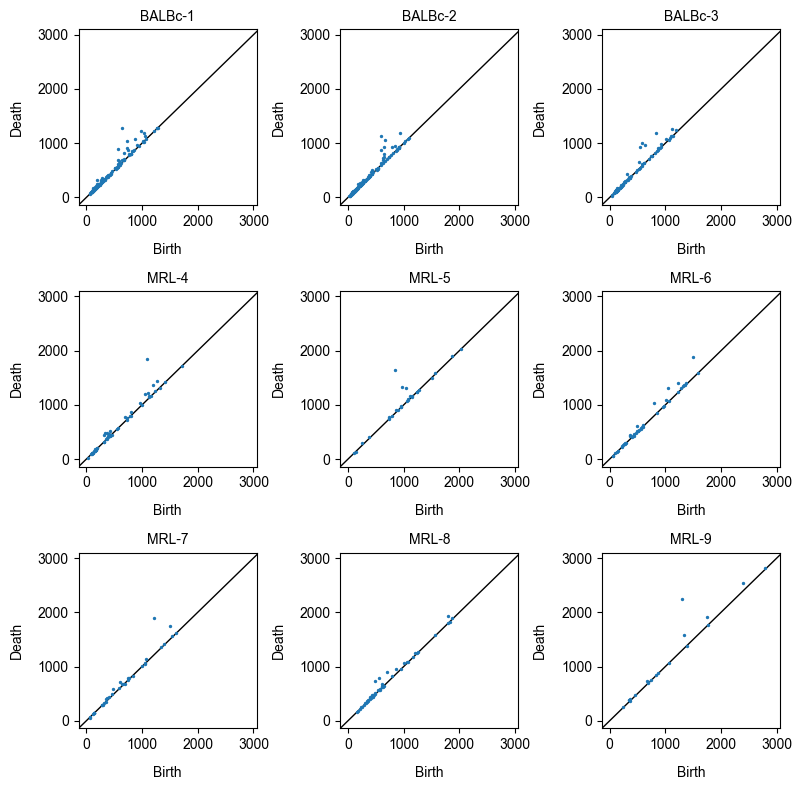

In [39]:
# Plot persistence diagram

fig, axs = plt.subplots(3, 3, figsize=(8, 8), layout = 'tight')

x_max, y_max = np.vstack(dgms[filtration][ct][degree]).max(axis=0)

for i in range(0,len(samples)):    
    sample = samples[i]

    ax = axs[math.floor(i/3), i%3]
    ax.set_title(sample, fontsize=10)
    ax.set_xlim(-x_max*0.05,x_max*1.1)
    ax.set_ylim(-y_max*0.05,y_max*1.1)
    ax.set_xlabel('Birth', labelpad = 10.0)
    ax.set_ylabel('Death', labelpad = 10.0)

    # Diagonal line
    ax.plot([-0.05*max(x_max,y_max),1.1*max(x_max,y_max)], [-0.05*max(x_max,y_max),1.1*max(x_max,y_max)], \
                color='black', linewidth = 1, zorder = 0) #, linestyle='dashed', zorder = 0)
    
    # Diagram
    dgm = dgms[filtration][ct][degree][i] 
    if len(dgm) > 0:
        ax.scatter(*np.array(dgm).T, s = 2)


## 3. PWDS Visualisation of PH

Example of PWDS for red and white pulp with alpha filtration.

In [40]:
# Chosen representative samples
examples_ind = [0,3]
examples = [samples[i] for i in examples_ind]
degree = 1
filt = 'alpha'

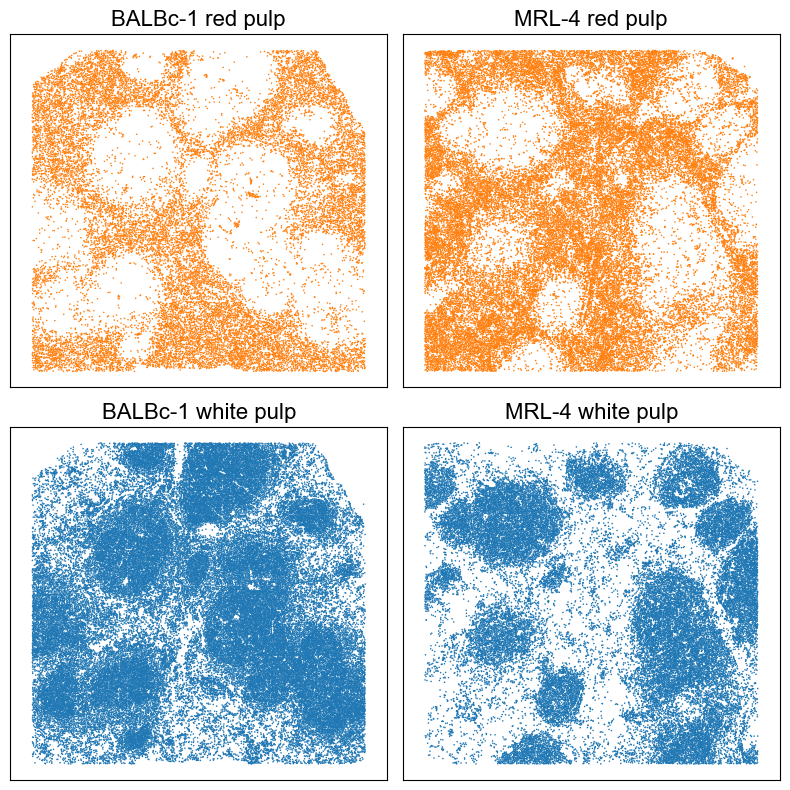

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes = axes.flatten()  # Flatten to make indexing easier

plot_idx = 0

for ct in broad_cell_types:
    for sample in examples:
        ax = axes[plot_idx]

        x = point_clouds[sample, ct][0]
        y = point_clouds[sample, ct][1]

        ax.set_title(f'{sample} {ct}', fontsize=16)
        ax.scatter(x, y, s=5, marker='.', edgecolors='none', color=ct2color[ct])
        ax.axis('equal')
        ax.set_xticks([])
        ax.set_yticks([])

        plot_idx += 1

plt.tight_layout()
plt.show()

In [42]:
# We define the birth thresholds as the average of the 90th and 98th percentiles of births in the diagram

birth_threshold = {}

for ct in broad_cell_types:
    percentiles_list_90 = [np.percentile(d, 90, axis=0)[0] for d in dgms[filt][ct][degree]]
    percentiles_list_98 = [np.percentile(d, 98, axis=0)[0] for d in dgms[filt][ct][degree]]
    birth_threshold[ct] = [np.mean(percentiles_list_90), np.mean(percentiles_list_98)]

In [43]:
# Choice of colours for the two regions of the diagram

colours_regions = ['firebrick','royalblue']

# Colour gradation between color1 and color2, with t ranging from 0 to 1

def adjust_color(color0, color1, t): # color0 and color1 correspond to color names
    c0 = matplotlib.colors.cnames[color0]
    r0, g0, b0 = matplotlib.colors.to_rgb(c0)
    c1 = matplotlib.colors.cnames[color1]
    r1, g1, b1 = matplotlib.colors.to_rgb(c1)

    return (r1 * t + (1.0 - t) * r0, g1 * t + (1.0 - t) * g0, b1 * t + (1.0 - t) * b0)

# Functions to adjust colour lightness of a colour

def adjust_lightness(color, a): # color needs to be (r, g, b)
    r, g, b = color
    R, G, B = (1,1,1) # White background

    return (r * a + (1.0 - a) * R, g * a + (1.0 - a) * G, b * a + (1.0 - a) * B)

# Lineal lightness adjustment 

def lightness(x, max_pers = 600):
    min_lightness = 0.2
    max_lightness = 1
    return (min_lightness + (x[1]-x[0])*(max_lightness-min_lightness)/max_pers)

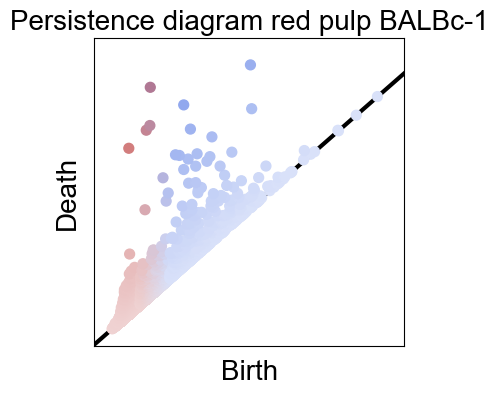

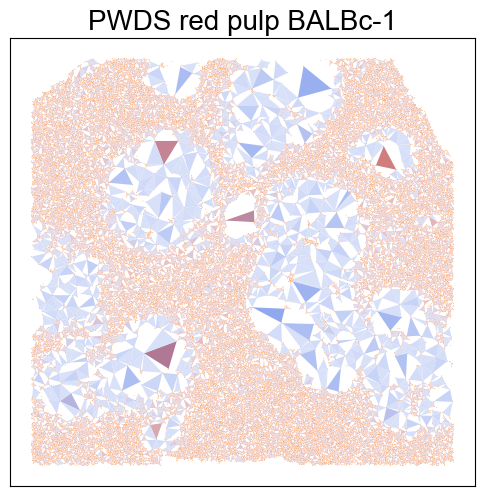

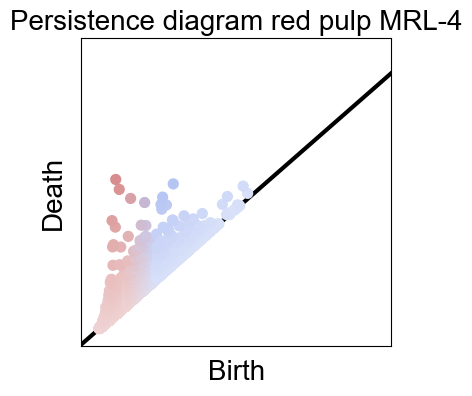

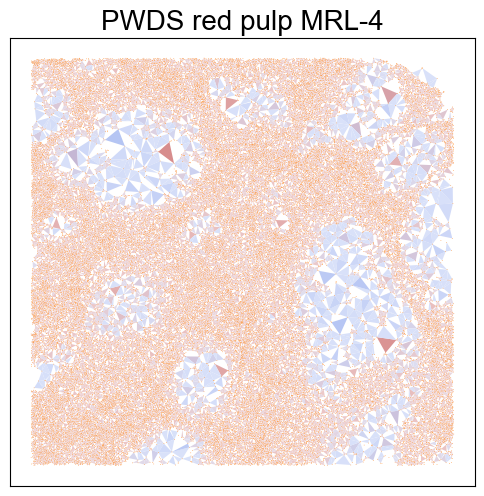

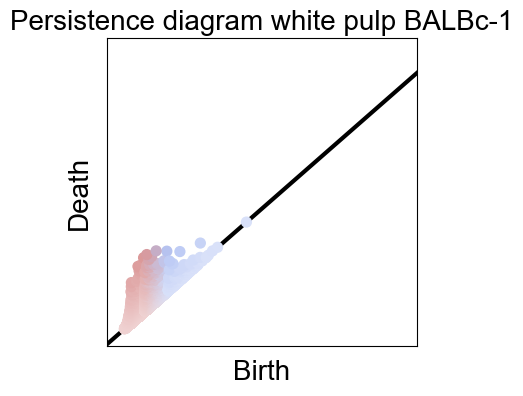

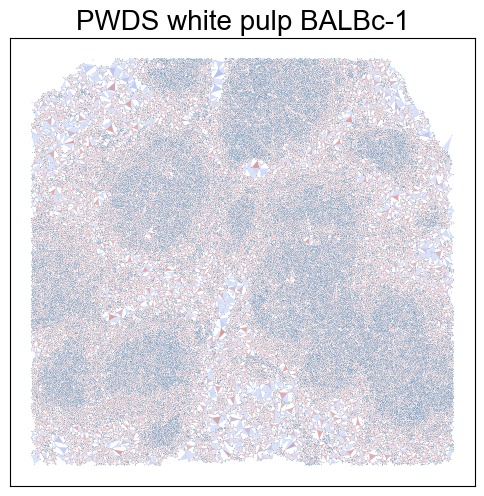

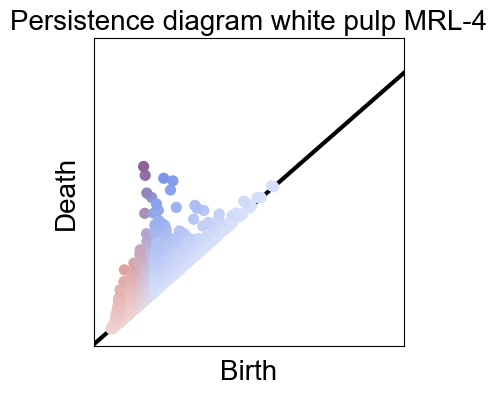

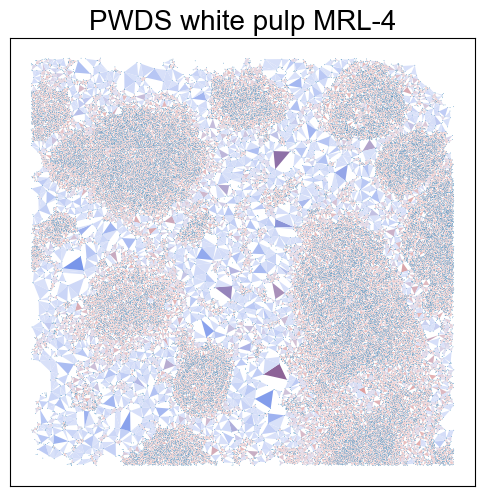

In [44]:
# Continuous change from red to blue

filt = 'alpha'
degree = 1
x_max, y_max = np.vstack([dgms[filt]['red pulp'][degree][i] for i in examples_ind]).max(axis=0)

for ct in broad_cell_types:
    for i in range(len(examples)):
        sample = examples[i]

        data = np.vstack((point_clouds[sample,ct][0], point_clouds[sample,ct][1])).T
        st = gudhi.AlphaComplex(points = data).create_simplex_tree()
        st.compute_persistence()

        simplices_dict = {tuple(sorted(s[0])) : s[1] for s in st.get_simplices()}
        pos = dict(zip(range(len(data)),[(list(x)[0],list(x)[1]) for x in data]))
        pers_pairs_1 = [x for x in st.persistence_pairs() if len(x[1]) == 3]
        point2simplex = {(np.sqrt(simplices_dict[tuple(sorted(x[0]))]), np.sqrt(simplices_dict[tuple(sorted(x[1]))])): x[1] for x in pers_pairs_1}

        num_regions = 3

        divided_dgm = [[] for _ in range(num_regions)]
        shaded_colors = [[] for _ in range(num_regions)]
        max_pers = np.ceil(max([x[1]-x[0] for x in np.vstack(dgms['alpha'][ct][degree])]))

        for x in point2simplex:
            if x[0] < birth_threshold[ct][0]: 
                r, g, b = matplotlib.colors.to_rgb(matplotlib.colors.cnames[colours_regions[0]])
                divided_dgm[0].append(tuple(x)) # proximal cells
                shaded_colors[0].append(adjust_lightness((r,g,b), lightness(x, max_pers=max_pers)))
            if (x[0] >= birth_threshold[ct][0]) and (x[0] <= birth_threshold[ct][1]):
                t = (x[0]- birth_threshold[ct][0])/(birth_threshold[ct][1]-birth_threshold[ct][0])
                divided_dgm[1].append(tuple(x)) # distal cells
                shaded_colors[1].append(adjust_lightness(adjust_color(colours_regions[0], colours_regions[1], t), lightness(x, max_pers=max_pers)))
            if x[0] > birth_threshold[ct][1]:
                r, g, b = matplotlib.colors.to_rgb(matplotlib.colors.cnames[colours_regions[1]])
                divided_dgm[2].append(tuple(x)) # distal cells
                shaded_colors[2].append(adjust_lightness((r,g,b), lightness(x, max_pers=max_pers)))

        # PLOT PERSISTENCE DIAGRAM

        fig = plt.figure(figsize=(4, 4), facecolor='white')

        plt.title('Persistence diagram ' + ct+' '+sample, size = 20)
        plt.xlim(-x_max*0.05,x_max*1.1)
        plt.ylim(-y_max*0.05,y_max*1.1)
        plt.xlabel('Birth', size=20, labelpad = 10.0)
        plt.ylabel('Death', size=20, labelpad = 10.0)
        plt.xticks([], [])
        plt.yticks([], [])
        
        # Diagonal line
        plt.plot([-0.05*max(x_max,y_max),1.1*max(x_max,y_max)], [-0.05*max(x_max,y_max),1.1*max(x_max,y_max)], \
                 color='black', linewidth = 3, zorder = 0) 
        
        # Points in persistence diagram
        for r in range(num_regions):
            if len(divided_dgm[r]) > 0:
                plt.scatter(*np.array(divided_dgm[r]).T,s=50, color = shaded_colors[r], zorder=1); 

        # PLOT DEATH SIMPLICES

        fig, ax = plt.subplots(figsize=(6, 6))
        ax.set_xticks([], [])
        ax.set_yticks([], [])
        ax.set_title('PWDS ' + ct+' '+sample, size = 20)

        plt.scatter(*np.array(data).T, s=1, marker = '.', color = ct2color[ct],edgecolors ='none',zorder = 4);

        for r in range(num_regions)[:]:

            triangles = [point2simplex[x]+[lightness(x, max_pers=max_pers)] for x in divided_dgm[r]]
            ax.set_aspect('equal')

            for l in range(len(triangles)):
                i, j, k, s = triangles[l]
                (x0, y0) = pos[i]
                (x1, y1) = pos[j]
                (x2, y2) = pos[k]
                tri = plt.Polygon([ [ x0, y0 ], [ x1, y1 ], [ x2, y2 ] ],
                                    edgecolor = None, facecolor = shaded_colors[r][l], #colours_regions[r],
                                    zorder = r, lw=0.5) #alpha=s
                ax.add_patch(tri);

## 4. Vectorisations

In [45]:
topological_descriptors = {}

### Betti curves

In [46]:
# Computing Betti curves

step = 1

for filt in filtrations:
    for ct in broad_cell_types + cell_types:
        if ct in dgms[filt]: 
            for degree in [0,1]:
                dgms_list = dgms[filt][ct][degree]
                if 0 not in [len(dgm) for dgm in dgms_list]: # Check there are no empty diagrams 
                    v = topological_descriptor(betti_curves(dgms_list, step, normalise = True),ct,filt,degree,'betti')
                    topological_descriptors[v.label] = v

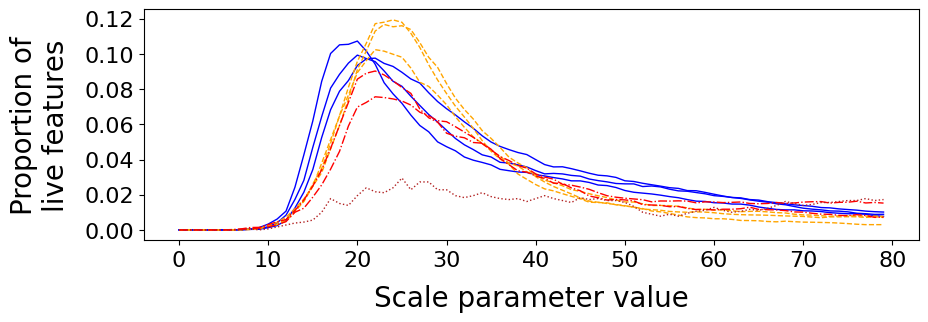

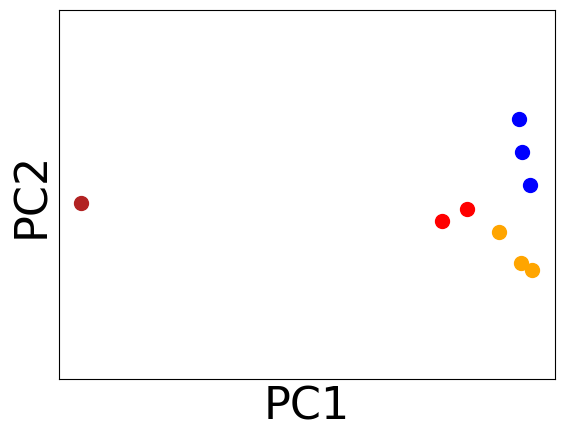

In [47]:
# Choose cell type, degree and max_param
ct = 'B cells'
degree = 1
max_param = 80

v = topological_descriptors[ct+' alpha H1 betti']
plot_betti_curves(v.vectors,step=1, max_param= max_param, legend = False, save=False);
plot_pca(v.vectors, ticks = False, legend = False, save=False);

### Elementary statistics

In [48]:
births = [10,12,4,14,16] # Percentiles of births (50th == median)
deaths = [11,13,5,15,17] # Percentiles of deaths (50th == median)
lengths = list(range(32,35 + 1)) + [29] # Percentiles of lengths of the bars (and median)

subsets = {'percentiles births': births, 'percentiles deaths': deaths, 'percentiles lengths': lengths}

for filt in filtrations:
    for ct in cell_types + broad_cell_types:
        if ct in dgms[filt]: 
            for degree in [0, 1]: 
                dgms_list = dgms[filt][ct][degree]
                if 0 not in [len(dgm) for dgm in dgms_list]:
                    pers_stats = [GetPersStats(d) for d in dgms_list]
                    if degree == 0:
                        key = 'percentiles lengths'
                        v = topological_descriptor([s[subsets[key]] for s in pers_stats],ct,filt,degree,'stats '+key)
                        topological_descriptors[v.label] = v
                    if degree == 1:
                        for key in subsets:
                            v = topological_descriptor([s[subsets[key]] for s in pers_stats],ct,filt,degree,'stats '+key)
                            topological_descriptors[v.label] = v

### Persistence images

In [49]:
# Weights

def flat_0(b,p, **kwargs):
    lower = nnd_mean / 2
    high = 1.0
    return np.piecewise(p,[p <= lower, p> lower],[lambda p: high*p/lower,lambda p: high])

def flat_1(b,p, **kwargs):
    lower = (1/np.sqrt(3)-1/2)*nnd_mean
    high = 1.0
    return np.piecewise(p,[p <= lower, p> lower],[lambda p: high*p/lower,lambda p: high])

def pers(b,p, **kwargs):
    return p

def pers2(b,p, **kwargs):
    return p**2

def birthpers(b,p, **kwargs):
    return b*p

def birthpers2(b,p, **kwargs):
    return b*p**2

custom_weights_0 = {'flat': flat_0,'p': pers, 'p^2': pers2} # we don't weigh the x-axis for PH0

custom_weights_1 = {'flat': flat_1,'p': pers, 'p^2': pers2, 'bp': birthpers, 'bp^2': birthpers2}

custom_weights = [custom_weights_0, custom_weights_1]

In [50]:
# Deciding resolutions based on small scale and maximum persistence values

size_pxl = {}

for point_cloud in broad_cell_types:
    size_pxl[point_cloud,'alpha', 0] = 10
    size_pxl[point_cloud,'alpha', 1] = 25
    size_pxl[point_cloud,'witness', 1] = 50

for point_cloud in cell_types:
    size_pxl[point_cloud,'alpha', 0] = 10
    size_pxl[point_cloud,'alpha', 1] = 25

size_sigma = size_pxl # We set the variance of the Gaussians to be the same as the size of the pixels. 

In [51]:
# Computation of persistence images

for ct in broad_cell_types + cell_types:
    for filt in filtrations:
        for degree in [0,1]:
            if (ct,filt,degree) in size_pxl: # We don't have all the possible combinations

                dgms_list = dgms[filt][ct][degree]

                if 0 not in [len(dgm) for dgm in dgms_list]: # If some diagrams are empty, we don't compute the vectorisations

                    if degree==0:
                        # TRICK: in order to get persistence images from a PD where all points have the same birth value,
                        # we add an artificial point at (1,0) for each diagram. Since the weighting function needs to be 0 
                        # at y-x = 0, this point will not contribute to the persistence surface.

                        for i in range(len(dgms_list)):
                            dgms_list[i] = np.concatenate((dgms_list[i], np.array([[1,1]])), axis=0)

                    pxl = size_pxl[ct,filt,degree]
                    sigma = size_sigma[ct,filt,degree]

                    for weight_label in custom_weights[degree]: 
                        pimgr = PersistenceImager(pixel_size=pxl)
                        pimgr.fit(dgms_list)

                        # Choose a linear weight function to give more importance to higher persistence features
                        pimgr.weight = custom_weights[degree][weight_label]

                        # Choose a higher variance of the gaussian functions centered at each point
                        pimgr.kernel_params = {'sigma': sigma}

                        # Compute and create top descriptor object
                        pi = topological_descriptor(vectors=pimgr.transform(dgms_list, skew=True), point_cloud=ct,\
                                                    filtration=filt, degree=degree, type='persim w='+weight_label)

                        pi.pi_shape = np.shape(pi.vectors[0]) # All images have the same shape. This allows us to recover the image later to plot it

                        # Save flattened vectors and add topological_descriptor to list
                        pi.vectors = np.array([image.flatten() for image in pi.vectors])

                        topological_descriptors[pi.label] = pi

#### Visualise persistence images

In [52]:
# Choose an example

pi = topological_descriptors['red pulp alpha H1 persim w=p^2']

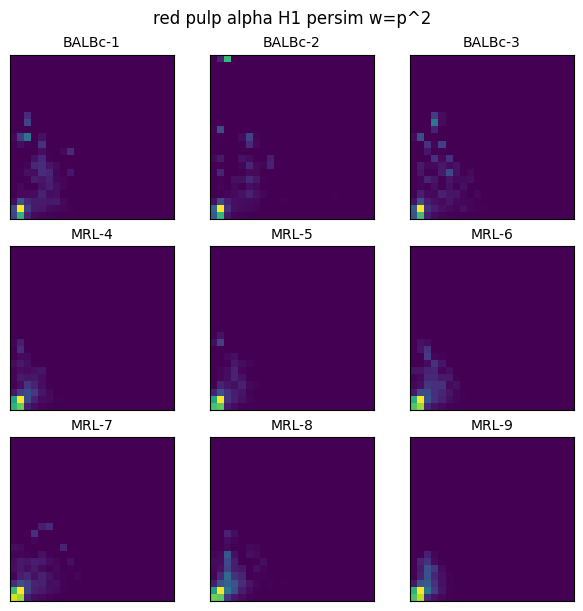

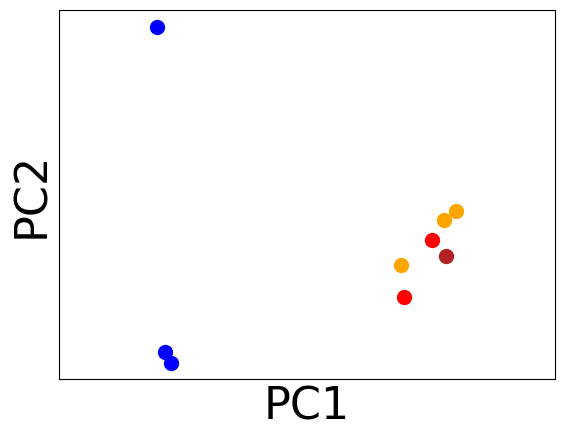

In [53]:
# Plot PI

fig, axs = plt.subplots(3, 3, figsize=(6,6),layout = 'constrained')
fig.suptitle(pi.label)

for i in range(len(samples)):    
    ax = axs[math.floor(i/3), i%3]
    pimgr.plot_image(np.reshape(pi.vectors[i],pi.pi_shape), ax)
    ax.set_title(samples[i], fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')

plot_pca(pi.vectors, ticks = False, legend = False, save=False);

## 5. Clustering

### Computation

In [54]:
# Computation of clustering

for key in topological_descriptors:
    v = topological_descriptors[key]

    # 2-clustering
    km = KMeans(n_clusters = 2, n_init=100).fit(v.vectors) # n_init=100
    v.twoclust = km.labels_.tolist()
    
    # 4-clustering
    km = KMeans(n_clusters = 4, n_init=100).fit(v.vectors) # n_init=100
    v.fourclust = km.labels_.tolist()
    
    # 3-clustering
    km = KMeans(n_clusters = 3,n_init=100).fit(v.vectors[stages_len[0]:])
    v.threeclust = km.labels_.tolist()

/home/torrasperez/Documents/Multiplexed data analysis/tda-venv/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (2). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/torrasperez/Documents/Multiplexed data analysis/tda-venv/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (4). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/torrasperez/Documents/Multiplexed data analysis/tda-venv/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (3). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
/home/torrasperez/Documents/Multiplexed data analysis/tda-venv/lib/python3.12/site-packages/sklearn/base.py:1473: ConvergenceWarning: Nu

### Evaluation and table of results

In [55]:
true_labels_2 = stages_len[0]*[0]+sum(stages_len[1:])*[1]

true_labels_4 = []
for i in range(len(stages_len)):
    true_labels_4+=stages_len[i]*[i]

true_labels_3 = true_labels_4[stages_len[0]:]

In [56]:
headers = ['Point cloud', 'Filtration', 'Degree','Vectorisation', '2-clustering', '4-clustering', '4-clust separates healthy', '3-clustering']

# Create a results data frame
results_df = pd.DataFrame(columns=headers)

for ct in broad_cell_types + cell_types:
    keys_ct = [k for k in topological_descriptors if topological_descriptors[k].point_cloud == ct]
    for filt in filtrations:
        keys_filtr = [k for k in keys_ct if topological_descriptors[k].filtration == filt]
        for degree in [0,1]:
            keys_degree = [k for k in keys_filtr if topological_descriptors[k].degree == degree]
            for key in keys_degree:
                v = topological_descriptors[key]
                res = [v.point_cloud, v.filtration, '$H_'+str(v.degree)+'$']

                if v.type[:6]=='persim':
                    res.append('persim '+ '$' + v.type[7:]+ '$')
                else:
                    res.append(v.type)
                
                # 2-clustering evaluation with silhouette score
                if good_clustering(v.twoclust,true_labels_2):
                    silhouette = round(sil_score(v.vectors, v.twoclust),4)
                    res.append(str(silhouette))
                else:
                    res.append(str('--'))

                # 4-clustering evaluation with silhouette score
                if good_clustering(v.fourclust,true_labels_4):
                    silhouette = round(sil_score(v.vectors, v.fourclust),4)
                    res.append(str(silhouette))
                else:
                    res.append(str('--'))

                # 4-clustering separates helthy
                if partial_clustering(v.fourclust,true_labels_4, [0]):
                    res.append('Y')
                else:
                    res.append('N')

                # 3-clustering evaluation with silhouette score
                if good_clustering(v.threeclust,true_labels_3):
                    silhouette = round(sil_score(v.vectors[stages_len[0]:], v.threeclust),3)
                    res.append(str(silhouette))
                else:
                    res.append(str('--'))

                results_df.loc[len(results_df)] = res

results_df.head(5)

,Point cloud,Filtration,Degree,Vectorisation,2-clustering,4-clustering,4-clust separates healthy,3-clustering
0,red pulp,alpha,$H_0$,betti,0.6702,--,N,--
1,red pulp,alpha,$H_0$,stats percentiles lengths,0.6283,--,N,--
2,red pulp,alpha,$H_0$,persim $w=flat$,0.6942,--,N,--
3,red pulp,alpha,$H_0$,persim $w=p$,0.647,--,N,--
4,red pulp,alpha,$H_0$,persim $w=p^2$,0.5387,--,N,--


In [57]:
# Insert a column with density to order results by cell type density

if "Density" not in results_df:
    results_df.insert(0, "Density", [np.mean(densities[ct]) for ct in results_df['Point cloud']])

In [58]:
# Only positive results, sorted by density of cell type, degree of homology and quality of the clustering

positive_results_sorted = results_df[(results_df['2-clustering']!= '--') | (results_df['4-clustering']!= '--')].sort_values(['Density','Degree','2-clustering'], ascending=[False,True,False])

pd.set_option("display.max_rows",None) 
positive_results_sorted

,Density,Point cloud,Filtration,Degree,Vectorisation,2-clustering,4-clustering,4-clust separates healthy,3-clustering
25,48365.000000,white pulp,alpha,$H_0$,persim $w=flat$,0.6359,--,Y,--
26,48365.000000,white pulp,alpha,$H_0$,persim $w=p$,0.5755,--,Y,--
32,48365.000000,white pulp,alpha,$H_1$,persim $w=flat$,0.6481,--,N,--
28,48365.000000,white pulp,alpha,$H_1$,betti,0.6181,--,N,--
31,48365.000000,white pulp,alpha,$H_1$,stats percentiles lengths,0.5975,--,N,--
41,48365.000000,white pulp,witness,$H_1$,persim $w=flat$,0.5873,--,Y,--
33,48365.000000,white pulp,alpha,$H_1$,persim $w=p$,0.5807,--,N,--
37,48365.000000,white pulp,witness,$H_1$,betti,0.4521,--,N,--
34,48365.000000,white pulp,alpha,$H_1$,persim $w=p^2$,0.427,--,Y,--
36,48365.000000,white pulp,alpha,$H_1$,persim $w=bp^2$,0.3394,--,Y,--
